# SIVE — Analisi comparativa sweep temperatura (t=0.2 / 0.5 / 0.7)

Questo notebook analizza i tre run completi di DeepSeek (`deepseek/deepseek-chat`)
eseguiti con il `sive_harness` a temperature crescenti.

**Domanda scientifica centrale**: la temperatura è un parametro di *robustezza* o di *effetto*?
Cioè, i risultati qualitativi (ranking delle condizioni, ordine dei gruppi LOW/MED/HIGH,
pattern di sensibilità) reggono across t=0.2..0.7, o cambiano significativamente?

**Struttura dell'analisi**:
1. Caricamento e normalizzazione dei 3 dataset
2. QC baseline: anomaly rate e copertura per run
3. **C1 — Fidelity**: correlazione PRE vs encoding latente `fiducia_istituzione`
4. **C2 — Stability**: correlazione inter-condizione sui PRE (stesso agente, condizioni diverse)
5. **C3 — Noise floor**: variabilità POS vs POS2 (condizioni identiche, replica), criterio ROPE
6. **C4 — Specificity**: effetto placebo (PLA vs CTRL), criterio ROPE
7. **C5 — Sensitivity**: delta POST-PRE per condizione, per gruppo LOW/MED/HIGH
8. **C6 — Ordering**: ranking condizioni coerente con il disegno sperimentale
9. Analisi item-per-item: `fiducia`, `credibilita`, `adeguatezza_info`, `emozione`, `intenzione`
10. Rumore e varianza: come la temperatura modifica la dispersione intra-gruppo
11. Distribuzione delle scelte categoriali (`emozione`, `intenzione`) per condizione e temperatura
12. Riepilogo comparativo: heatmap temperatura × criterio


## 1 · Setup e caricamento dati

Montiamo Drive, definiamo le path dei 3 run e carichiamo i profili originali.
I profili servono per recuperare `T_latent` e `attitudini` di ciascun agente,
che non vengono mai esposti al modello durante il run (necessario per la validità
del criterio C1: il modello non 'sa' il proprio encoding).

**Formato dei dati**: ogni run ha un file `survey_{COND}.csv` per condizione
(checkpoint incrementale) e un `survey_FINAL.csv` (snapshot cumulativa). Usiamo
il FINAL dove presente, altrimenti concateniamo i checkpoint per condizione;
per i run in cui manca il FINAL (interruzione dell'ultima cella), la
concatenazione è equivalente.


In [6]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from pathlib import Path
from google.colab import drive

drive.mount('/content/drive')

# ── Path dei 4 run completi ───────────────────────────────────────────────────
BASE_DIR = Path('/content/drive/MyDrive/Colab Notebooks/SyntheticPopulation/SIVE/results_minimal2')

RUNS = {
    0.2: BASE_DIR / 'deepseek_deepseek-chat_t02_20260623_072828',
    0.5: BASE_DIR / 'deepseek_deepseek-chat_t05_20260623_204124',
    0.7: BASE_DIR /'deepseek_deepseek-chat_t07_20260625_171143'
}

# ── Profili: encoding latente e attitudini di riferimento ────────────────────
# Adatta il path se il file è in una posizione diversa sul tuo Drive
PROFILE_PATH = '/content/drive/MyDrive/Colab Notebooks/SyntheticPopulation/SIVE/sive_120_completi.json'
with open(PROFILE_PATH, encoding='utf-8') as f:
    PROFILI = json.load(f)

META = {p['id']: p for p in PROFILI}
GRUPPI = {g: [p['id'] for p in PROFILI if p['gruppo'] == g] for g in ['LOW', 'MED', 'HIGH']}

# Encoding latente fiducia_istituzione per ciascun agente (scala 1-10)
ENC = pd.Series({p['id']: p['attitudini']['fiducia_istituzione'] for p in PROFILI}, dtype=float)
# Encoding latente per tutti e tre i numeric items
ENC_ALL = pd.DataFrame({
    item: {p['id']: p['attitudini'].get(item, np.nan) for p in PROFILI}
    for item in ['fiducia_istituzione', 'credibilita', 'adeguatezza_info']
}, dtype=float)

CONDITIONS = ['POS', 'POS2', 'POSW', 'POSW2', 'NEG', 'PLA', 'CTRL']
NUMERIC_ITEMS = ['fiducia_istituzione', 'credibilita', 'adeguatezza_info']
CHOICE_ITEMS  = ['emozione', 'intenzione']
TEMPERATURES  = sorted(RUNS.keys())

print('Profili caricati:', len(PROFILI))
print('Gruppi:', {g: len(v) for g, v in GRUPPI.items()})
print('Run disponibili:', list(RUNS.keys()))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Profili caricati: 120
Gruppi: {'LOW': 40, 'MED': 40, 'HIGH': 40}
Run disponibili: [0.2, 0.5, 0.7]


In [7]:
def load_run(run_dir: Path) -> pd.DataFrame:
    """
    Carica i dati survey di un run.
    Strategia: usa survey_FINAL_v2.csv se esiste (contiene originale + POSW2),
    altrimenti tenta survey_FINAL.csv, altrimenti concatena i checkpoint
    per condizione (incluso survey_POSW2.csv se presente).
    Aggiunge la colonna 'gruppo' leggendola dai profili.
    """
    final_v2 = run_dir / 'survey_FINAL_v2.csv'
    final    = run_dir / 'survey_FINAL.csv'

    if final_v2.exists():
        df = pd.read_csv(final_v2)
    elif final.exists():
        # Prova ad appendere POSW2 separato se esiste
        df = pd.read_csv(final)
        posw2_path = run_dir / 'survey_POSW2.csv'
        if posw2_path.exists():
            posw2 = pd.read_csv(posw2_path)
            df = pd.concat([df, posw2], ignore_index=True)
            df = df.drop_duplicates(subset=['agent_id', 'condition', 'phase', 'item'])
    else:
        parts = []
        for c in CONDITIONS:
            p = run_dir / f'survey_{c}.csv'
            if p.exists():
                parts.append(pd.read_csv(p))
        df = pd.concat(parts, ignore_index=True)

    if 'gruppo' not in df.columns:
        df['gruppo'] = df['agent_id'].map(lambda aid: META[aid]['gruppo'])

    df['value_num'] = pd.to_numeric(df['value'], errors='coerce')
    return df


DATA = {t: load_run(d) for t, d in RUNS.items()}

for t, df in DATA.items():
    conds = sorted(df['condition'].unique())
    has_posw2 = 'POSW2' in conds
    print(f't={t}: {len(df)} righe, {df["agent_id"].nunique()} agenti, '
          f'{len(conds)} condizioni — POSW2: {"✅" if has_posw2 else "⚠️  assente"}')
    print(f'       condizioni: {conds}')


t=0.2: 9240 righe, 120 agenti, 7 condizioni — POSW2: ✅
       condizioni: ['CTRL', 'NEG', 'PLA', 'POS', 'POS2', 'POSW', 'POSW2']
t=0.5: 29040 righe, 120 agenti, 7 condizioni — POSW2: ✅
       condizioni: ['CTRL', 'NEG', 'PLA', 'POS', 'POS2', 'POSW', 'POSW2']
t=0.7: 29040 righe, 120 agenti, 7 condizioni — POSW2: ✅
       condizioni: ['CTRL', 'NEG', 'PLA', 'POS', 'POS2', 'POSW', 'POSW2']


## 2 · QC baseline: anomaly rate e copertura

Per ogni run calcoliamo:
- **Anomaly rate**: percentuale di risposte `value=NaN` sui soli item numerici
  (fiducia, credibilita, adeguatezza_info). Un valore nullo su item di scelta
  (emozione, intenzione) indica che il modello non ha restituito un'opzione valida.
- **Copertura**: agenti completati per condizione (deve essere 120/120 per tutti i run inclusi).

L'anomaly rate è la prima metrica da osservare in un sweep di temperatura:
temperature alte tendono a produrre risposte non conformi al formato atteso
(es. testo invece di numero intero).

In [9]:
qc_rows = []
for t, df in DATA.items():
    # Anomalie sui numerici
    num_df = df[df['item'].isin(NUMERIC_ITEMS)]
    anom_num = num_df['value_num'].isna().sum()
    rate_num = anom_num / len(num_df) * 100

    # Anomalie sui categoriali (value None/nan)
    cat_df = df[df['item'].isin(CHOICE_ITEMS)]
    anom_cat = cat_df['value'].isna().sum()
    rate_cat = anom_cat / len(cat_df) * 100 if len(cat_df) > 0 else np.nan

    # Copertura: min agenti per condizione
    cov = df.groupby('condition')['agent_id'].nunique()
    min_cov = cov.min()

    qc_rows.append({
        'temperatura': t,
        'righe_totali': len(df),
        'anomalie_num': anom_num,
        'anomaly_rate_num_%': round(rate_num, 3),
        'anomalie_cat': anom_cat,
        'anomaly_rate_cat_%': round(rate_cat, 3),
        'min_agenti_per_condizione': min_cov,
    })

qc_df = pd.DataFrame(qc_rows)
print('=== QC BASELINE ===')
print(qc_df.to_string(index=False))

=== QC BASELINE ===
 temperatura  righe_totali  anomalie_num  anomaly_rate_num_%  anomalie_cat  anomaly_rate_cat_%  min_agenti_per_condizione
         0.2          9240             0                 0.0             3               0.089                        120
         0.5         29040             0                 0.0             8               0.076                        120
         0.7         29040             0                 0.0             3               0.028                        120


## 3 · C1 — Fidelity: correlazione PRE vs encoding latente

Il criterio C1 verifica che i punteggi PRE delle personas siano coerenti con
il loro encoding latente `fiducia_istituzione` (che il modello non ha mai visto).
Una correlazione alta (r > 0.8) indica che il sistema prompt del profilo trasmette
efficacemente l'attitudine di partenza.

Lo calcoliamo:
- Sulla condizione POS (la più usata come riferimento)
- Su tutti e tre gli item numerici (fiducia, credibilita, adeguatezza_info)
- Per ciascuna temperatura

Ci aspettiamo che la correlazione sia **stabile across temperature**: C1 misura
la codifica del profilo nel PRE, prima di qualsiasi intervento, e il PRE è
identico per tutte le condizioni della stessa persona. Se C1 cala con T alta,
significa che la variabilità stocastica del modello sta mascherando il segnale
di profilo già nella fase baseline.

In [10]:
def fidelity_by_item(df, condition='POS'):
    """
    Correlazione di Pearson tra punteggio PRE e encoding latente,
    per ciascun item numerico. Ritorna un dict {item: r}.
    """
    sub = df[(df['condition'] == condition) & (df['phase'] == 'PRE') &
             (df['item'].isin(NUMERIC_ITEMS))]
    out = {}
    for item in NUMERIC_ITEMS:
        s = sub[sub['item'] == item].set_index('agent_id')['value_num'].dropna()
        enc_item = ENC_ALL[item].reindex(s.index).dropna()
        common = s.index.intersection(enc_item.index)
        if len(common) > 5:
            r, p = stats.pearsonr(s[common], enc_item[common])
            out[item] = (round(r, 3), round(p, 4), len(common))
        else:
            out[item] = (np.nan, np.nan, len(common))
    return out


print('=== C1 FIDELITY: correlazione PRE (cond=POS) vs encoding latente ===')
print(f'{"temperatura":>12} | {"fiducia_r":>10} {"credib_r":>10} {"adeguatezza_r":>14}')
print('-' * 55)

c1_data = {}
for t in TEMPERATURES:
    res = fidelity_by_item(DATA[t])
    c1_data[t] = {k: v[0] for k, v in res.items()}
    vals = [f"{res[i][0]:.3f} (p={res[i][1]:.4f})" for i in NUMERIC_ITEMS]
    print(f't={t:>8}   | {res["fiducia_istituzione"][0]:>10.3f} '
          f'{res["credibilita"][0]:>10.3f} '
          f'{res["adeguatezza_info"][0]:>14.3f}')

# ── Medie PRE per gruppo LOW/MED/HIGH (criterio dell'ordine crescente) ────────
print('\n=== C1 SUPPLEMENTO: medie PRE per gruppo (condizione POS) ===')
print(f'{"temperatura":>12} | {"LOW":>8} {"MED":>8} {"HIGH":>8} | ordine?')
print('-' * 55)
for t in TEMPERATURES:
    df = DATA[t]
    sub = df[(df['condition'] == 'POS') & (df['phase'] == 'PRE') &
             (df['item'] == 'fiducia_istituzione')]
    gm = {g: sub[sub['agent_id'].isin(GRUPPI[g])]['value_num'].mean() for g in ['LOW', 'MED', 'HIGH']}
    ordered = gm['LOW'] < gm['MED'] < gm['HIGH']
    print(f't={t:>8}   | {gm["LOW"]:>8.2f} {gm["MED"]:>8.2f} {gm["HIGH"]:>8.2f} | {"✅" if ordered else "❌"}')

=== C1 FIDELITY: correlazione PRE (cond=POS) vs encoding latente ===
 temperatura |  fiducia_r   credib_r  adeguatezza_r
-------------------------------------------------------
t=     0.2   |      0.891      0.858          0.762
t=     0.5   |      0.911      0.825          0.828
t=     0.7   |      0.900      0.869          0.814

=== C1 SUPPLEMENTO: medie PRE per gruppo (condizione POS) ===
 temperatura |      LOW      MED     HIGH | ordine?
-------------------------------------------------------
t=     0.2   |     2.58     5.30     7.08 | ✅
t=     0.5   |     2.35     5.40     7.65 | ✅
t=     0.7   |     2.48     5.40     7.28 | ✅


## 4 · C2 — Stability: correlazione inter-condizione sui PRE

Lo stesso agente affronta la batteria PRE *prima* di ricevere qualsiasi messaggio,
identicamente in tutte e 6 le condizioni (within-subjects design). Quindi i PRE
di condizioni diverse per lo stesso agente devono essere quasi identici.

Calcoliamo la correlazione di Pearson tra i vettori PRE di tutte le coppie di
condizioni (15 coppie) e riportiamo il **minimo** come metrica conservativa.
Un r_min alto (> 0.90) conferma che il modello risponde in modo stabile al profilo
indipendentemente dall'ordine di presentazione delle condizioni.

La stability è particolarmente sensibile alla temperatura: a T alta il modello
campiona da una distribuzione più piatta, introducendo variabilità "gratuita"
non legata al profilo.

In [11]:
def stability_matrix(df, item='fiducia_istituzione'):
    """
    Matrice di correlazione tra i PRE di tutte le coppie di condizioni.
    Ogni colonna è il vettore dei punteggi PRE di tutti gli agenti
    per quella condizione.
    """
    sub = df[(df['phase'] == 'PRE') & (df['item'] == item)]
    pivot = sub.pivot_table(index='agent_id', columns='condition',
                            values='value_num', aggfunc='mean')
    return pivot.corr()


print('=== C2 STABILITY: correlazione inter-condizione (PRE, fiducia_istituzione) ===')
print(f'{"temperatura":>12} | {"r_min":>8} {"r_mean":>8} {"r_max":>8}')
print('-' * 48)

c2_data = {}
for t in TEMPERATURES:
    corr = stability_matrix(DATA[t])
    # Prendi solo il triangolo superiore (senza diagonale)
    vals = corr.values[np.triu_indices_from(corr.values, k=1)]
    c2_data[t] = {'min': vals.min(), 'mean': vals.mean(), 'max': vals.max()}
    print(f't={t:>8}   | {vals.min():>8.3f} {vals.mean():>8.3f} {vals.max():>8.3f}')



=== C2 STABILITY: correlazione inter-condizione (PRE, fiducia_istituzione) ===
 temperatura |    r_min   r_mean    r_max
------------------------------------------------
t=     0.2   |    0.858    0.893    0.915
t=     0.5   |    0.866    0.897    0.917
t=     0.7   |    0.876    0.906    0.922


## 5 · C3 — Noise floor: POS vs POS2 (replica identica)

POS e POS2 ricevono lo **stesso identico messaggio**: qualunque differenza
nei rispettivi delta riflette esclusivamente il rumore del processo
generativo, non un effetto di trattamento reale. Calcoliamo la
distribuzione di (delta_POS − delta_POS2) per agente e ne riportiamo due
componenti: la deviazione standard (C3a, caratteristica strumentale
analoga alla risoluzione di misura, non un pass/fail) e la media (C3b,
il bias di replica). Per C3b adottiamo un criterio ROPE
(|mean| < 0.5 punti scala) anziché un test di significatività puro: a
n=120 il test classico ha potenza sufficiente a rigettare media=0 anche
per bias scientificamente irrilevanti.


In [12]:
def delta_series_full(df, condition, item='fiducia_istituzione'):
    """
    Calcola delta = POST - PRE per tutti gli agenti, per una condizione e item dati.
    Ritorna una Series indicizzata per agent_id.
    """
    pre = (df[(df['condition'] == condition) & (df['phase'] == 'PRE') & (df['item'] == item)]
           .set_index('agent_id')['value_num'])
    post = (df[(df['condition'] == condition) & (df['phase'] == 'POST') & (df['item'] == item)]
            .set_index('agent_id')['value_num'])
    return (post - pre).dropna()


print('=== C3 NOISE FLOOR: delta(POS) - delta(POS2) per fiducia_istituzione ===')
print(f'{"temperatura":>12} | {"sd_diff":>8} {"mean_diff":>10} {"t-stat":>8} {"p-val":>8}')
print('-' * 60)

c3_data = {}
for t in TEMPERATURES:
    d1 = delta_series_full(DATA[t], 'POS')
    d2 = delta_series_full(DATA[t], 'POS2')
    diff = (d1 - d2).dropna()
    tstat, pval = stats.ttest_1samp(diff, 0)
    c3_data[t] = {'sd': diff.std(), 'mean': diff.mean(), 't': tstat, 'p': pval}
    print(f't={t:>8}   | {diff.std():>8.3f} {diff.mean():>10.3f} {tstat:>8.3f} {pval:>8.4f}')

print('\nInterpretazione: sd_diff è il noise floor (C3a, unità scala 1-10).')
print('C3b — ROPE: |mean_diff| < 0.5 punti scala (non un test p > 0.05).')
for t in TEMPERATURES:
    status = 'PASS' if abs(c3_data[t]['mean']) < 0.5 else 'FAIL'
    print(f'  t={t}: mean_diff={c3_data[t]["mean"]:+.3f} -> {status} (ROPE)')

=== C3 NOISE FLOOR: delta(POS) - delta(POS2) per fiducia_istituzione ===
 temperatura |  sd_diff  mean_diff   t-stat    p-val
------------------------------------------------------------
t=     0.2   |    1.399      0.008    0.065   0.9481
t=     0.5   |    1.384      0.050    2.168   0.0302
t=     0.7   |    1.299      0.117    5.390   0.0000

Interpretazione: sd_diff è il noise floor (unità scala 1-10).
p > 0.05 → nessun bias sistematico tra POS e POS2 (atteso).


## 6 · C4 — Specificity: effetto placebo (PLA vs CTRL)

La condizione PLA riceve un messaggio neutro, tematicamente ortogonale
alla rete idrica e alla fiducia istituzionale (la festa di quartiere).
Se lo strumento è specifico — risponde al contenuto dello stimolo, non
alla sua semplice presenza — il delta di PLA deve essere praticamente
indistinguibile da quello di CTRL (nessun messaggio). Come per C3b,
adottiamo qui un criterio ROPE (|mean diff| < 0.5 punti scala) anziché
un test di significatività puro, per la stessa ragione: a n=120 il
t-test ha ampia potenza per rigettare media=0 anche per un bias troppo
piccolo per essere rilevante.


In [13]:
print('=== C4 SPECIFICITY: effetto placebo (PLA vs CTRL) ===')
print(f'{"temperatura":>12} | {"delta_PLA":>10} {"delta_CTRL":>11} {"PLA-CTRL":>10} {"p":>8}')
print('-' * 62)

c4_data = {}
for t in TEMPERATURES:
    d_pla  = delta_series_full(DATA[t], 'PLA')
    d_ctrl = delta_series_full(DATA[t], 'CTRL')
    diff   = (d_pla - d_ctrl).dropna()
    tstat, pval = stats.ttest_1samp(diff, 0)
    c4_data[t] = {'delta_pla': d_pla.mean(), 'delta_ctrl': d_ctrl.mean(),
                  'diff': diff.mean(), 'p': pval}
    print(f't={t:>8}   | {d_pla.mean():>+10.3f} {d_ctrl.mean():>+11.3f} '
          f'{diff.mean():>+10.3f} {pval:>8.4f}')

print('\nC4 — ROPE: |mean diff| < 0.5 punti scala (non un test p > 0.05).')
for t in TEMPERATURES:
    status = 'PASS' if abs(c4_data[t]['diff']) < 0.5 else 'FAIL'
    print(f'  t={t}: PLA-CTRL={c4_data[t]["diff"]:+.3f} -> {status} (ROPE)')
print('Se CTRL < 0 sistematicamente: possibile effetto risomministrazione (regression to mean).')

=== C4 SPECIFICITY: effetto placebo (PLA vs CTRL) ===
 temperatura |  delta_PLA  delta_CTRL   PLA-CTRL        p
--------------------------------------------------------------
t=     0.2   |     -0.067      -0.042     -0.025   0.8558
t=     0.5   |     -0.025      -0.067     +0.042   0.6099
t=     0.7   |     +0.000      +0.058     -0.058   0.4420

Atteso: PLA-CTRL vicino a 0 (p > 0.05).
Se CTRL < 0 sistematicamente: possibile effetto risomministrazione (regression to mean).


## 7 · C5 — Sensitivity: delta POST-PRE per condizione e per gruppo

Questo è il criterio più ricco: verifica che le personas reagiscano in modo
**differenziato** alle condizioni sperimentali, con un pattern coerente con
il disegno:

- **POS** > **POS2** ≈ 0 (replica, deve coincidere)
- **POS** > **POSW2** > **CTRL** (positivo forte > positivo debole ricalibrato > controllo)
- **POSW** < **CTRL** (finding: valenza funzionale negativa del testo originale)
- **NEG** < **CTRL** (negativo abbassa la fiducia)
- **PLA** ≈ **CTRL** (placebo non sposta)

E per il pattern di gruppo:
- Il gruppo **LOW** (bassa fiducia di partenza) risponde di più a POS
  (maggiore spazio per crescere)
- Il gruppo **HIGH** (alta fiducia) risponde di più a NEG
  (maggiore spazio per scendere)

Analizziamo per tutti e tre gli item numerici e mostriamo come la temperatura
modifica l'ampiezza degli effetti (attenuazione vs amplificazione).

In [14]:
# ── Delta per condizione × temperatura, item = fiducia_istituzione ────────────
print('=== C5 SENSITIVITY: delta POST-PRE medio per condizione (fiducia_istituzione) ===')
header = f'{"temperatura":>12} | ' + ' '.join(f'{c:>7}' for c in CONDITIONS)
print(header)
print('-' * len(header))

delta_table = {}
for t in TEMPERATURES:
    row = {}
    for c in CONDITIONS:
        d = delta_series_full(DATA[t], c)
        row[c] = d.mean()
    delta_table[t] = row
    vals = ' '.join(f'{row[c]:>+7.3f}' for c in CONDITIONS)
    print(f't={t:>8}   | {vals}')

# ── Delta per gruppo × condizione (solo POS e NEG, item fiducia) ──────────────
print('\n=== C5 SUPPLEMENTO: delta per GRUPPO (POS e NEG, fiducia_istituzione) ===')
for condition in ['POS', 'POSW2', 'POSW', 'NEG']:
    print(f'\n  Condizione {condition}:')
    print(f'  {"temperatura":>12} | {"LOW":>8} {"MED":>8} {"HIGH":>8}')
    print('  ' + '-' * 44)
    for t in TEMPERATURES:
        df = DATA[t]
        gm = {}
        for g in ['LOW', 'MED', 'HIGH']:
            d = delta_series_full(df[df['agent_id'].isin(GRUPPI[g])], condition)
            gm[g] = d.mean()
        print(f'  t={t:>8}   | {gm["LOW"]:>+8.3f} {gm["MED"]:>+8.3f} {gm["HIGH"]:>+8.3f}')
# ── Confronto diretto POSW vs POSW2: il finding chiave del paper ─────────────
print('\n=== CONFRONTO POSW vs POSW2: finding chiave =========================')
print(f'{"temperatura":>12} | {"POSW":>8} {"POSW2":>8} | {"diff (POSW2-POSW)":>18} | {"p (t-test)":>12}')
print('-' * 68)
from scipy.stats import ttest_ind as _ttest
for t in TEMPERATURES:
    df = DATA[t]
    if 'POSW2' not in df['condition'].unique():
        print(f't={t:>8}   | {"n/a":>8} {"n/a":>8} | {"POSW2 non disponibile":>30}')
        continue
    d_posw  = delta_series_full(df, 'POSW')
    d_posw2 = delta_series_full(df, 'POSW2')
    tstat, pval = _ttest(d_posw2.dropna(), d_posw.dropna())
    diff = d_posw2.mean() - d_posw.mean()
    print(f't={t:>8}   | {d_posw.mean():>+8.3f} {d_posw2.mean():>+8.3f} | '
          f'{diff:>+18.3f} | {pval:>12.4f}')
print('\nInterpretazione: POSW aveva valenza funzionale negativa (testo ambiguo).')
print('POSW2 (ricalibrato) dovrebbe avere delta > 0 e > POSW (p < 0.05 = ricalibrazione efficace).')


=== C5 SENSITIVITY: delta POST-PRE medio per condizione (fiducia_istituzione) ===
 temperatura |     POS    POS2    POSW   POSW2     NEG     PLA    CTRL
----------------------------------------------------------------------
t=     0.2   |  +0.158  +0.150  -0.508  +0.108  -1.650  -0.067  -0.042
t=     0.5   |  +0.283  +0.233  -0.525  +0.008  -1.683  -0.025  -0.067
t=     0.7   |  +0.292  +0.175  -0.433  +0.200  -1.658  +0.000  +0.058

=== C5 SUPPLEMENTO: delta per GRUPPO (POS e NEG, fiducia_istituzione) ===

  Condizione POS:
   temperatura |      LOW      MED     HIGH
  --------------------------------------------
  t=     0.2   |   -0.350   +0.325   +0.500
  t=     0.5   |   +0.050   +0.475   +0.325
  t=     0.7   |   -0.075   +0.275   +0.675

  Condizione POSW2:
   temperatura |      LOW      MED     HIGH
  --------------------------------------------
  t=     0.2   |   -0.575   +0.250   +0.650
  t=     0.5   |   -0.950   +0.275   +0.700
  t=     0.7   |   -0.325   +0.225   +0.700

 

## 8 · C6 — Ordering: ranking condizioni coerente col disegno

Formalizziamo il test del ranking: per ciascuna temperatura verifichiamo
se l'ordinamento atteso delle condizioni sul delta fiducia è rispettato:

**Ordine atteso** (dal più alto al più basso delta):
`POS ≥ POS2 > POSW > PLA ≈ CTRL > NEG`

Usiamo il **rank correlation di Kendall** tra l'ordinamento osservato e quello atteso
come misura sintetica del rispetto del pattern (τ = 1 → ranking perfetto).

In [15]:
# Ordine atteso (ranking numerico: 1=più alto delta atteso)
# POSW2 è la versione ricalibrata di POSW — atteso debolmente positivo
# POSW retrocede al posto 6 perché ha valenza funzionale negativa (finding del paper)
EXPECTED_RANK = {'POS': 1, 'POS2': 2, 'POSW2': 3, 'CTRL': 4, 'PLA': 5, 'POSW': 6, 'NEG': 7}

print('=== C6 ORDERING: ranking condizioni vs ordine atteso ===')
print(f'{"temperatura":>12} | {"tau":>8} {"p":>8} | ranking osservato')
print('-' * 70)

for t in TEMPERATURES:
    deltas = delta_table[t]  # calcolato in C5
    # Ranking osservato (1=più alto delta)
    observed_order = sorted(CONDITIONS, key=lambda c: -deltas[c])
    obs_rank = {c: i+1 for i, c in enumerate(observed_order)}

    exp_vals = [EXPECTED_RANK[c] for c in CONDITIONS]
    obs_vals = [obs_rank[c] for c in CONDITIONS]
    tau, p = stats.kendalltau(obs_vals, exp_vals)
    ranking_str = ' > '.join(observed_order)
    print(f't={t:>8}   | {tau:>8.3f} {p:>8.4f} | {ranking_str}')

print('\nAtteso: tau vicino a 1.0 (p < 0.05 → ordinamento non casuale).')

=== C6 ORDERING: ranking condizioni vs ordine atteso ===
 temperatura |      tau        p | ranking osservato
----------------------------------------------------------------------
t=     0.2   |    1.000   0.0004 | POS > POS2 > POSW2 > CTRL > PLA > POSW > NEG
t=     0.5   |    0.905   0.0028 | POS > POS2 > POSW2 > PLA > CTRL > POSW > NEG
t=     0.7   |    0.905   0.0028 | POS > POSW2 > POS2 > CTRL > PLA > POSW > NEG

Atteso: tau vicino a 1.0 (p < 0.05 → ordinamento non casuale).


## 9 · Analisi item-per-item: tutti e 3 i numerici

Finora abbiamo usato `fiducia_istituzione` come item di riferimento (quello
con encoding latente più discriminante). Ora estendiamo l'analisi a tutti
e tre gli item numerici per verificare se i pattern sono consistenti
o se alcuni item sono più sensibili/stabili di altri.

Mostriamo una tabella di delta per condizione × item × temperatura.

In [16]:
for item in NUMERIC_ITEMS:
    print(f'\n=== Item: {item} ===')
    print(f'{"temperatura":>12} | ' + ' '.join(f'{c:>8}' for c in CONDITIONS))
    print('-' * 70)
    for t in TEMPERATURES:
        row = []
        for c in CONDITIONS:
            d = delta_series_full(DATA[t], c, item=item)
            row.append(d.mean())
        vals = ' '.join(f'{v:>+8.3f}' for v in row)
        print(f't={t:>8}   | {vals}')


=== Item: fiducia_istituzione ===
 temperatura |      POS     POS2     POSW    POSW2      NEG      PLA     CTRL
----------------------------------------------------------------------
t=     0.2   |   +0.158   +0.150   -0.508   +0.108   -1.650   -0.067   -0.042
t=     0.5   |   +0.283   +0.233   -0.525   +0.008   -1.683   -0.025   -0.067
t=     0.7   |   +0.292   +0.175   -0.433   +0.200   -1.658   +0.000   +0.058

=== Item: credibilita ===
 temperatura |      POS     POS2     POSW    POSW2      NEG      PLA     CTRL
----------------------------------------------------------------------
t=     0.2   |   +0.692   +0.733   -0.150   +0.458   -0.633   +0.233   -0.033
t=     0.5   |   +0.900   +0.808   -0.183   +0.258   -0.775   +0.058   -0.042
t=     0.7   |   +0.892   +0.892   -0.225   +0.783   -0.742   +0.125   +0.058

=== Item: adeguatezza_info ===
 temperatura |      POS     POS2     POSW    POSW2      NEG      PLA     CTRL
--------------------------------------------------------------

## 10 · Rumore e varianza intra-gruppo

La temperatura influenza non solo i valori medi ma anche la **dispersione**.
Con T alta ci aspettiamo:
- Maggiore varianza intra-gruppo (le personas dello stesso gruppo divergono di più)
- Minore separazione inter-gruppo (i tre cluster LOW/MED/HIGH si sovrappongono di più)

Calcoliamo per ciascuna temperatura:
- Deviazione standard dei PRE per gruppo (varianza baseline)
- Deviazione standard dei delta POST-PRE per condizione (varianza effetto)
- Rapporto segnale/rumore approssimativo: `|delta_POS - delta_NEG| / sd_noise`

In [17]:
print('=== VARIANZA: sd dei PRE per gruppo (fiducia_istituzione, cond=POS) ===')
print(f'{"temperatura":>12} | {"sd_LOW":>8} {"sd_MED":>8} {"sd_HIGH":>8} | {"sd_delta_POS":>13} {"SNR":>8}')
print('-' * 72)

for t in TEMPERATURES:
    df = DATA[t]
    sub = df[(df['condition'] == 'POS') & (df['phase'] == 'PRE') &
             (df['item'] == 'fiducia_istituzione')]
    sd = {g: sub[sub['agent_id'].isin(GRUPPI[g])]['value_num'].std() for g in ['LOW','MED','HIGH']}

    d_pos = delta_series_full(df, 'POS')
    d_neg = delta_series_full(df, 'NEG')
    d_pos2 = delta_series_full(df, 'POS2')

    # noise floor dal confronto POS vs POS2
    noise = (d_pos - d_pos2).dropna().std()
    # segnale = separazione POS - NEG
    signal = d_pos.mean() - d_neg.mean()
    snr = signal / noise if noise > 0 else np.nan

    print(f't={t:>8}   | {sd["LOW"]:>8.3f} {sd["MED"]:>8.3f} {sd["HIGH"]:>8.3f} | '
          f'{d_pos.std():>13.3f} {snr:>8.2f}')

print('\nSNR = (delta_POS - delta_NEG) / sd_noise_floor')
print('SNR > 2 → effetto sperimentale chiaramente rilevabile sopra il rumore.')

=== VARIANZA: sd dei PRE per gruppo (fiducia_istituzione, cond=POS) ===
 temperatura |   sd_LOW   sd_MED  sd_HIGH |  sd_delta_POS      SNR
------------------------------------------------------------------------
t=     0.2   |    0.958    0.464    0.888 |         1.053     1.29
t=     0.5   |    0.939    0.701    0.728 |         1.035     1.42
t=     0.7   |    1.002    0.626    0.776 |         1.099     1.50

SNR = (delta_POS - delta_NEG) / sd_noise_floor
SNR > 2 → effetto sperimentale chiaramente rilevabile sopra il rumore.


## 11 · Distribuzione scelte categoriali (emozione e intenzione)

Gli item categoriali (`emozione` e `intenzione`) non hanno una metrica numerica
di delta, ma la distribuzione delle scelte POST vs PRE è un indicatore qualitativo
della direzione della risposta.

Per ciascuna condizione e temperatura mostriamo:
- La distribuzione marginale delle scelte nell'item `emozione` in fase POST
- Il confronto PRE vs POST per la condizione POS (atteso: shift verso 'speranza')
- Il confronto PRE vs POST per la condizione NEG (atteso: shift verso 'preoccupazione' o 'rabbia')

La temperatura dovrebbe aumentare l'entropia della distribuzione: a T=0.2 il modello
potrebbe scegliere quasi sempre la stessa emozione 'dominante', a T=0.7 (la più alta
nella nostra sweep) la distribuzione dovrebbe essere relativamente più piatta.

In [18]:
EMOZIONI   = ['sollievo', 'preoccupazione', 'rabbia', 'speranza', 'indifferenza']
INTENZIONI = ['cercare piu informazioni', 'parlare con i vicini',
               'partecipare a incontri pubblici', 'non cambiera nulla', 'contattare il comune']

def choice_dist(df, item, condition, phase):
    """Distribuzione percentuale delle scelte per un item categoriale."""
    sub = df[(df['condition'] == condition) & (df['phase'] == phase) & (df['item'] == item)]
    return sub['value'].value_counts(normalize=True).mul(100).round(1)


# ── Emozione POST per condizione POS e NEG, a confronto tra temperature ───────
for cond in ['POS', 'NEG']:
    print(f'\n=== EMOZIONE POST — condizione {cond} ===')
    rows = []
    for t in TEMPERATURES:
        dist = choice_dist(DATA[t], 'emozione', cond, 'POST')
        row = {'T': t}
        for em in EMOZIONI:
            row[em] = dist.get(em, 0.0)
        rows.append(row)
    dist_df = pd.DataFrame(rows).set_index('T')
    print(dist_df.to_string())

# ── Entropia della distribuzione emozione (misura di piattezza) ───────────────
print('\n=== ENTROPIA distribuzione emozione POST per condizione × temperatura ===')
print(f'{"temperatura":>12} | ' + ' '.join(f'{c:>8}' for c in CONDITIONS))
print('-' * 70)
for t in TEMPERATURES:
    entropies = []
    for c in CONDITIONS:
        dist = choice_dist(DATA[t], 'emozione', c, 'POST')
        probs = dist.values / 100.0
        probs = probs[probs > 0]
        H = -np.sum(probs * np.log(probs)) if len(probs) > 0 else 0
        entropies.append(H)
    vals = ' '.join(f'{H:>8.3f}' for H in entropies)
    print(f't={t:>8}   | {vals}')
print('\nH_max(5 opzioni) = {:.3f} nats. Più alto = distribuzione più piatta.'.format(np.log(5)))


=== EMOZIONE POST — condizione POS ===
     sollievo  preoccupazione  rabbia  speranza  indifferenza
T                                                            
0.2       0.0            15.0    28.3      56.7           0.0
0.5       0.0            15.8    28.3      55.8           0.0
0.7       0.0             9.2    30.8      59.2           0.8

=== EMOZIONE POST — condizione NEG ===
     sollievo  preoccupazione  rabbia  speranza  indifferenza
T                                                            
0.2       0.0            41.2    53.8       5.0           0.0
0.5       0.0            40.0    55.8       4.2           0.0
0.7       0.0            35.0    56.7       8.3           0.0

=== ENTROPIA distribuzione emozione POST per condizione × temperatura ===
 temperatura |      POS     POS2     POSW    POSW2      NEG      PLA     CTRL
----------------------------------------------------------------------
t=     0.2   |    0.964    1.071    1.158    1.279    0.849    0.898    0.79

## 12 · Visualizzazioni comparative

Tre plot principali:

1. **Delta per condizione × temperatura** (lineplot): come cambia la risposta
   media a ciascuna condizione al variare della temperatura.

2. **PRE per gruppo** (boxplot): distribuzione dei PRE per LOW/MED/HIGH a
   ciascuna temperatura — verifica visiva del C1.

3. **Heatmap riepilogativa**: temperatura × criterio (C1..C6), con colori
   che indicano il livello di soddisfacimento.

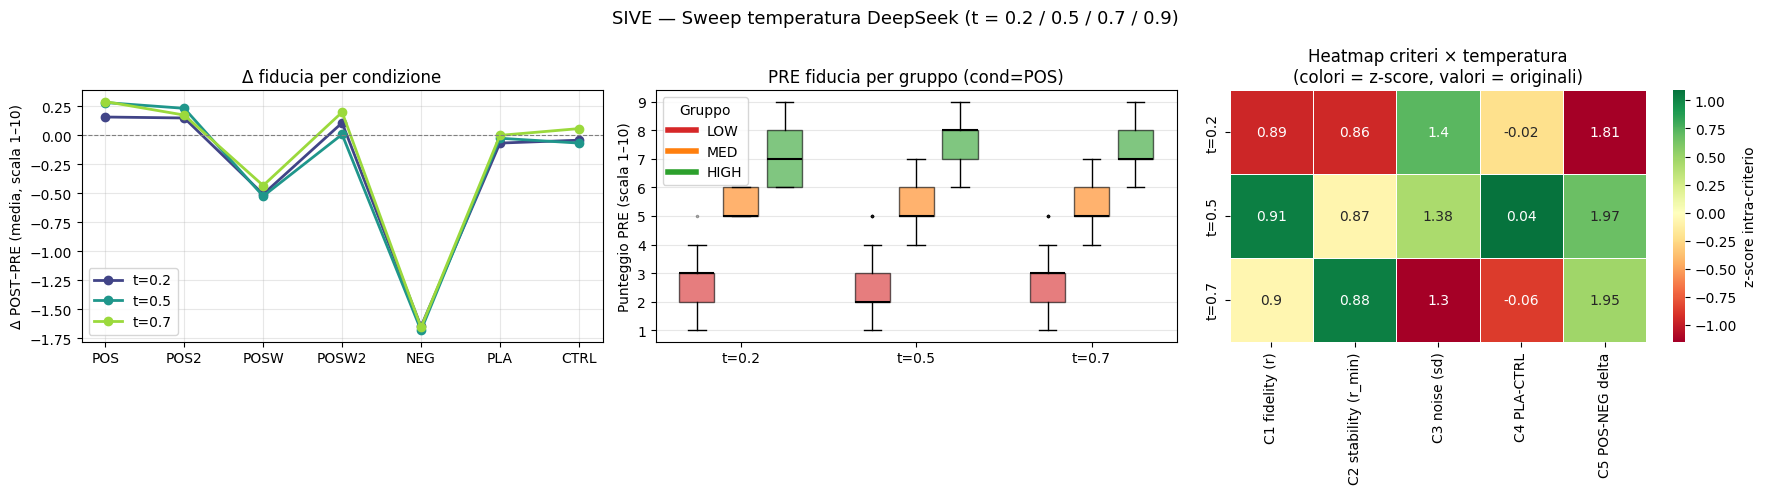

Plot salvato in /content/sive_temperature_analysis.png


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('SIVE — Sweep temperatura DeepSeek (t = 0.2 / 0.5 / 0.7)', fontsize=13)

# ── Plot 1: delta per condizione × temperatura ─────────────────────────────────
ax = axes[0]
colors = plt.cm.viridis(np.linspace(0.2, 0.85, len(TEMPERATURES)))
for i, t in enumerate(TEMPERATURES):
    deltas = [delta_table[t][c] for c in CONDITIONS]
    ax.plot(CONDITIONS, deltas, 'o-', color=colors[i], label=f't={t}', linewidth=2, markersize=6)
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_title('Δ fiducia per condizione')
ax.set_ylabel('Δ POST–PRE (media, scala 1–10)')
ax.legend()
ax.grid(True, alpha=0.3)

# ── Plot 2: PRE per gruppo a ciascuna temperatura (boxplot) ───────────────────
ax = axes[1]
all_pre = []
for t in TEMPERATURES:
    df = DATA[t]
    sub = df[(df['condition'] == 'POS') & (df['phase'] == 'PRE') &
             (df['item'] == 'fiducia_istituzione')].copy()
    sub['temperatura'] = t
    all_pre.append(sub)
pre_df = pd.concat(all_pre)
groups_ordered = ['LOW', 'MED', 'HIGH']
offsets = {'LOW': -0.25, 'MED': 0, 'HIGH': 0.25}
colors_g = {'LOW': '#d62728', 'MED': '#ff7f0e', 'HIGH': '#2ca02c'}
for g in groups_ordered:
    sub_g = pre_df[pre_df['agent_id'].isin(GRUPPI[g])]
    positions = [i + offsets[g] for i, t in enumerate(TEMPERATURES)]
    data_by_t = [sub_g[sub_g['temperatura'] == t]['value_num'].dropna().values
                 for t in TEMPERATURES]
    bp = ax.boxplot(data_by_t, positions=positions, widths=0.2,
                    patch_artist=True, manage_ticks=False,
                    boxprops=dict(facecolor=colors_g[g], alpha=0.6),
                    medianprops=dict(color='black', linewidth=1.5),
                    whiskerprops=dict(linewidth=1), capprops=dict(linewidth=1),
                    flierprops=dict(marker='.', markersize=3, alpha=0.4))
    ax.plot([], [], color=colors_g[g], linewidth=4, label=g)
ax.set_xticks(range(len(TEMPERATURES)))
ax.set_xticklabels([f't={t}' for t in TEMPERATURES])
ax.set_title('PRE fiducia per gruppo (cond=POS)')
ax.set_ylabel('Punteggio PRE (scala 1–10)')
ax.legend(title='Gruppo')
ax.grid(True, alpha=0.3, axis='y')

# ── Plot 3: heatmap criteri × temperatura ─────────────────────────────────────
ax = axes[2]
# Costruiamo la matrice: ogni cella è il valore numerico del criterio
heat_data = {
    'C1 fidelity (r)':    [c1_data[t]['fiducia_istituzione'] for t in TEMPERATURES],
    'C2 stability (r_min)': [c2_data[t]['min'] for t in TEMPERATURES],
    'C3 noise (sd)':      [c3_data[t]['sd'] for t in TEMPERATURES],
    'C4 PLA-CTRL':        [c4_data[t]['diff'] for t in TEMPERATURES],
    'C5 POS-NEG delta':   [delta_table[t]['POS'] - delta_table[t]['NEG'] for t in TEMPERATURES],
}
heat_df = pd.DataFrame(heat_data, index=[f't={t}' for t in TEMPERATURES])
# Normalizziamo per colonna (z-score) così i colori sono comparabili
heat_norm = heat_df.apply(lambda col: (col - col.mean()) / col.std() if col.std() > 0 else col, axis=0)
sns.heatmap(heat_norm, ax=ax, cmap='RdYlGn', center=0, annot=heat_df.round(2),
            fmt='g', linewidths=0.5, cbar_kws={'label': 'z-score intra-criterio'})
ax.set_title('Heatmap criteri × temperatura\n(colori = z-score, valori = originali)')
ax.set_xlabel('')

plt.tight_layout()
plt.savefig('/content/sive_temperature_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot salvato in /content/sive_temperature_analysis.png')

## 13 · Report riepilogativo

Tabella sinottica finale con tutti i criteri e un giudizio sintetico
per ciascuna temperatura. Serve come punto di partenza per la sezione
di risultati del GSP paper.

In [20]:
print('=' * 78)
print('SIVE TEMPERATURE SWEEP — REPORT RIEPILOGATIVO')
print('Modello: deepseek/deepseek-chat | 120 agenti × 7 condizioni')
print('=' * 78)

for t in TEMPERATURES:
    df = DATA[t]
    qc = qc_df[qc_df['temperatura'] == t].iloc[0]

    d_pos = delta_series_full(df, 'POS')
    d_neg = delta_series_full(df, 'NEG')
    d_pla = delta_series_full(df, 'PLA')
    d_ctrl = delta_series_full(df, 'CTRL')
    d_pos2 = delta_series_full(df, 'POS2')

    noise = (d_pos - d_pos2).dropna().std()
    snr   = (d_pos.mean() - d_neg.mean()) / noise if noise > 0 else np.nan

    print(f'\n── T = {t} ──────────────────────────────────────────────────────')
    print(f'  QC:         anomaly_num={qc["anomaly_rate_num_%"]:.3f}% | '
          f'anomaly_cat={qc["anomaly_rate_cat_%"]:.3f}%')
    print(f'  C1 fidelity: r={c1_data[t]["fiducia_istituzione"]:.3f} '
          f'(credib={c1_data[t]["credibilita"]:.3f}, '
          f'adeg={c1_data[t]["adeguatezza_info"]:.3f})')
    print(f'  C2 stability: r_min={c2_data[t]["min"]:.3f} | r_mean={c2_data[t]["mean"]:.3f}')
    print(f'  C3 noise floor: sd={c3_data[t]["sd"]:.3f} | '
          f'mean_diff={c3_data[t]["mean"]:+.3f} (p={c3_data[t]["p"]:.4f})')
    print(f'  C4 specificity: PLA-CTRL={c4_data[t]["diff"]:+.3f} (p={c4_data[t]["p"]:.4f})')
    print(f'  C5 sensitivity: POS={d_pos.mean():+.3f} | NEG={d_neg.mean():+.3f} | '
          f'POS-NEG={d_pos.mean()-d_neg.mean():.3f}')
    print(f'  SNR (POS-NEG / noise_floor): {snr:.2f}')
    print(f'  Delta per condizione: '
          + ' | '.join(f'{c}={delta_table[t][c]:+.3f}' for c in CONDITIONS))

print('\n' + '=' * 78)
print('Fine report. Salva questo output come riferimento per il GSP paper.')
print('=' * 78)

SIVE TEMPERATURE SWEEP — REPORT RIEPILOGATIVO
Modello: deepseek/deepseek-chat | 120 agenti × 6 condizioni × 2 campagne

── T = 0.2 ──────────────────────────────────────────────────────
  QC:         anomaly_num=0.000% | anomaly_cat=0.089%
  C1 fidelity: r=0.891 (credib=0.858, adeg=0.762)
  C2 stability: r_min=0.858 | r_mean=0.893
  C3 noise floor: sd=1.399 | mean_diff=+0.008 (p=0.9481)
  C4 specificity: PLA-CTRL=-0.025 (p=0.8558)
  C5 sensitivity: POS=+0.158 | NEG=-1.650 | POS-NEG=1.808
  SNR (POS-NEG / noise_floor): 1.29
  Delta per condizione: POS=+0.158 | POS2=+0.150 | POSW=-0.508 | POSW2=+0.108 | NEG=-1.650 | PLA=-0.067 | CTRL=-0.042

── T = 0.5 ──────────────────────────────────────────────────────
  QC:         anomaly_num=0.000% | anomaly_cat=0.076%
  C1 fidelity: r=0.911 (credib=0.825, adeg=0.828)
  C2 stability: r_min=0.866 | r_mean=0.897
  C3 noise floor: sd=1.384 | mean_diff=+0.050 (p=0.0302)
  C4 specificity: PLA-CTRL=+0.042 (p=0.6099)
  C5 sensitivity: POS=+0.283 | NEG=-1

In [ ]:
# ── Salvataggio opzionale su Drive ───────────────────────────────────────────
# Esporta il delta_table come CSV per uso successivo (es. sezione risultati paper)
OUT_DIR = BASE_DIR / 'analysis'
OUT_DIR.mkdir(parents=True, exist_ok=True)

delta_rows = []
for t in TEMPERATURES:
    for c in CONDITIONS:
        for item in NUMERIC_ITEMS:
            d = delta_series_full(DATA[t], c, item=item)
            delta_rows.append({
                'temperatura': t, 'condition': c, 'item': item,
                'delta_mean': d.mean(), 'delta_sd': d.std(), 'n': len(d)
            })

delta_export = pd.DataFrame(delta_rows)
delta_export.to_csv(OUT_DIR / 'sive_delta_by_temp_condition_item.csv', index=False)
print('Esportato:', OUT_DIR / 'sive_delta_by_temp_condition_item.csv')

# Esporta anche il QC summary
qc_df.to_csv(OUT_DIR / 'sive_qc_by_temperature.csv', index=False)
print('Esportato:', OUT_DIR / 'sive_qc_by_temperature.csv')

Esportato: /content/drive/MyDrive/Colab Notebooks/SyntheticPopulation/SIVE/results_minimal2/analysis/sive_delta_by_temp_condition_item.csv
Esportato: /content/drive/MyDrive/Colab Notebooks/SyntheticPopulation/SIVE/results_minimal2/analysis/sive_qc_by_temperature.csv


In [5]:
import shutil
from pathlib import Path

BASE_DIR = Path('/content/drive/MyDrive/Colab Notebooks/SyntheticPopulation/SIVE/results_minimal2')

target = BASE_DIR / 'deepseek_deepseek-chat_t07_20260626_091423'
if target.exists():
    shutil.rmtree(target)
    print(f'✅ Eliminato: {target.name}')
else:
    print(f'⚠️  Non trovato: {target.name}')

✅ Eliminato: deepseek_deepseek-chat_t07_20260626_091423
